In [6]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted


In [7]:
!pip install xgboost scikit-learn imbalanced-learn matplotlib seaborn --quiet
print('✅ Dependencies installed')

✅ Dependencies installed


In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib, json, os, random, warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import LabelEncoder
from sklearn.metrics          import (classification_report, accuracy_score,
                                      confusion_matrix, roc_curve, auc,
                                      precision_score, recall_score, f1_score)
from sklearn.preprocessing    import label_binarize
from imblearn.over_sampling   import SMOTE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print(f'✅ Imports done  |  XGBoost {xgb.__version__}  |  seed={SEED}')

✅ Imports done  |  XGBoost 3.2.0  |  seed=42


In [9]:
DRIVE_BASE = '/content/drive/MyDrive/MediScan_AI'
MODEL_DIR  = f'{DRIVE_BASE}/models'
GRAPH_DIR  = DRIVE_BASE
BASE       = f'{DRIVE_BASE}/dataset/symptoms'

os.makedirs(MODEL_DIR, exist_ok=True)
print('✅ Output folder:', MODEL_DIR)

✅ Output folder: /content/drive/MyDrive/MediScan_AI/models


In [10]:
df1 = pd.read_csv(f'{BASE}/Community Healthcare MultiSymptomsDisease Diagnostic Dataset.csv')
df2 = pd.read_csv(f'{BASE}/Final_Augmented_dataset_Diseases_and_Symptoms.csv')
df3 = pd.read_csv(f'{BASE}/lcs_synthetic_20000.csv')

print(f'✅ df1 shape: {df1.shape}')
print(f'✅ df2 shape: {df2.shape}')
print(f'✅ df3 shape: {df3.shape}')

✅ df1 shape: (100000, 175)
✅ df2 shape: (246945, 378)
✅ df3 shape: (20000, 16)


In [11]:
ALL_FEATURES = [
    'cough_severity', 'fever_severity', 'breathlessness_severity',
    'wheezing_severity', 'chest_pain_severity', 'fatigue_severity',
    'onset_speed', 'duration_level',
    'smell_taste_loss', 'muscle_aches',
    'night_sweats', 'tb_exposure',
    'blood_cough', 'weight_loss',
    'velcro_crackles',
    'wheezing_episodic', 'known_trigger', 'inhaler_reversal',
    'hoarseness',
    'leg_swelling', 'recent_immobility',
    'smoking_level', 'fever_pattern',
]

DISEASES = [
    'Asthma', 'Covid-19', 'Lung Cancer',
    'Pulmonary Embolism', 'Pulmonary Fibrosis', 'Tuberculosis',
]

SMOKING_MAP = {
    'non_smoker': 0, 'former': 1, 'occasional': 2, 'regular': 3, 'heavy': 4,
}

DURATION_MAP = {
    '1_3_days': 0, '1_week': 1, '1_month': 2, '3_months': 3,
}

print(f'✅ Feature count : {len(ALL_FEATURES)}')
print(f'✅ Disease count : {len(DISEASES)}')
for i, f in enumerate(ALL_FEATURES):
    print(f'   [{i:02d}] {f}')

✅ Feature count : 23
✅ Disease count : 6
   [00] cough_severity
   [01] fever_severity
   [02] breathlessness_severity
   [03] wheezing_severity
   [04] chest_pain_severity
   [05] fatigue_severity
   [06] onset_speed
   [07] duration_level
   [08] smell_taste_loss
   [09] muscle_aches
   [10] night_sweats
   [11] tb_exposure
   [12] blood_cough
   [13] weight_loss
   [14] velcro_crackles
   [15] wheezing_episodic
   [16] known_trigger
   [17] inhaler_reversal
   [18] hoarseness
   [19] leg_swelling
   [20] recent_immobility
   [21] smoking_level
   [22] fever_pattern


In [12]:
def frontend_to_features(severity: dict, adv_answers: dict,
                          smoking: str, duration: str) -> list:
    sev = {k: int(v) for k, v in severity.items()}
    adv = {k: int(bool(v)) for k, v in adv_answers.items()}

    cough_severity = max(
        sev.get('covid19', 0), sev.get('tuberculosis', 0),
        sev.get('lung_cancer', 0), sev.get('pulmonary_fibrosis', 0),
        sev.get('asthma', 0),
    )
    fever_severity = max(sev.get('covid19', 0), sev.get('tuberculosis', 0))
    breathlessness_severity = max(
        sev.get('pulmonary_embolism', 0), sev.get('pulmonary_fibrosis', 0),
        sev.get('covid19', 0), sev.get('asthma', 0), sev.get('lung_cancer', 0),
    )
    wheezing_severity   = sev.get('asthma', 0)
    chest_pain_severity = max(sev.get('pulmonary_embolism', 0), sev.get('lung_cancer', 0))
    fatigue_severity    = max(sev.get('lung_cancer', 0), sev.get('tuberculosis', 0), sev.get('covid19', 0))

    dur_int = DURATION_MAP.get(duration, 0)
    if sev.get('pulmonary_embolism', 0) >= 2 or sev.get('covid19', 0) >= 2:
        onset_speed = 3
    elif dur_int <= 1:
        onset_speed = 2
    elif dur_int == 2:
        onset_speed = 1
    else:
        onset_speed = 0

    duration_level    = dur_int
    smell_taste_loss  = adv.get('smell_taste_loss', 0)
    muscle_aches      = adv.get('muscle_aches', 0)
    night_sweats      = adv.get('drenching_sweats', 0)
    tb_exposure       = adv.get('tb_exposure', 0)
    blood_cough       = adv.get('blood_in_cough', 0)
    weight_loss       = max(adv.get('unexplained_wt', 0), adv.get('cancer_wt_loss', 0))
    velcro_crackles   = adv.get('velcro_crackles', 0)
    wheezing_episodic = adv.get('normal_between', 0)
    known_trigger     = adv.get('specific_trigger', 0)
    inhaler_reversal  = adv.get('inhaler_relief', 0)
    hoarseness        = adv.get('new_hoarseness', 0)
    leg_swelling      = adv.get('leg_swelling', 0)
    recent_immobility = adv.get('immobility_risk', 0)
    smoking_level     = SMOKING_MAP.get(smoking, 0)

    if adv.get('drenching_sweats', 0) or sev.get('tuberculosis', 0) >= 2:
        fever_pattern = 2
    elif sev.get('covid19', 0) >= 1:
        fever_pattern = 1
    else:
        fever_pattern = 0

    return [
        cough_severity, fever_severity, breathlessness_severity,
        wheezing_severity, chest_pain_severity, fatigue_severity,
        onset_speed, duration_level,
        smell_taste_loss, muscle_aches,
        night_sweats, tb_exposure,
        blood_cough, weight_loss,
        velcro_crackles,
        wheezing_episodic, known_trigger, inhaler_reversal,
        hoarseness,
        leg_swelling, recent_immobility,
        smoking_level, fever_pattern,
    ]

print('✅ frontend_to_features() defined')
_test = frontend_to_features(
    severity={'covid19': 2, 'tuberculosis': 1},
    adv_answers={'smell_taste_loss': True, 'muscle_aches': True},
    smoking='non_smoker', duration='1_week',
)
assert len(_test) == len(ALL_FEATURES)
print(f'   Sanity check: {len(_test)} features ✅')

✅ frontend_to_features() defined
   Sanity check: 23 features ✅


In [13]:
def generate_disease_samples(disease: str, n_samples: int, seed: int = 42) -> pd.DataFrame:
    rng  = np.random.RandomState(seed)
    rows = []

    for _ in range(n_samples):
        r = {}

        if disease == 'Covid-19':
            sev = rng.choice([1,2,3], p=[0.30,0.45,0.25])
            r['cough_severity']           = sev
            r['fever_severity']           = max(1, sev - 1 + rng.randint(0,2))
            r['breathlessness_severity']  = rng.choice([0,1,2,3], p=[0.50,0.25,0.15,0.10]) if sev == 3 else rng.choice([0,1], p=[0.80,0.20])
            r['wheezing_severity']        = 0
            r['chest_pain_severity']      = rng.choice([0,1], p=[0.70,0.30])
            r['fatigue_severity']         = rng.choice([1,2,3], p=[0.30,0.45,0.25])
            r['onset_speed']              = 3
            r['duration_level']           = rng.choice([1,2], p=[0.75,0.25])
            r['smell_taste_loss']         = int(rng.random() < 0.85)
            r['muscle_aches']             = int(rng.random() < 0.70)
            r['night_sweats']             = 0; r['tb_exposure'] = 0
            r['blood_cough']              = 0; r['weight_loss'] = 0
            r['velcro_crackles']          = 0; r['wheezing_episodic'] = 0
            r['known_trigger']            = 0; r['inhaler_reversal'] = 0
            r['hoarseness']               = 0; r['leg_swelling'] = 0
            r['recent_immobility']        = 0
            r['smoking_level']            = rng.choice([0,1,2,3,4], p=[0.50,0.15,0.15,0.12,0.08])
            r['duration_level']           = rng.choice([1,2], p=[0.80,0.20])
            r['fever_pattern']            = rng.choice([1,3], p=[0.65,0.35])

        elif disease == 'Pulmonary Fibrosis':
            sev = rng.choice([1,2,3], p=[0.25,0.45,0.30])
            r['cough_severity']           = sev
            r['fever_severity']           = 0
            r['breathlessness_severity']  = max(1, sev)
            r['wheezing_severity']        = 0
            r['chest_pain_severity']      = rng.choice([0,1,2], p=[0.55,0.35,0.10])
            r['fatigue_severity']         = rng.choice([0,1,2,3], p=[0.10,0.30,0.40,0.20])
            r['onset_speed']              = rng.choice([0,1], p=[0.85,0.15])
            r['duration_level']           = 3
            r['smell_taste_loss']         = 0; r['muscle_aches'] = 0
            r['night_sweats']             = 0; r['tb_exposure'] = 0
            r['blood_cough']              = 0
            r['weight_loss']              = int(rng.random() < 0.20)
            r['velcro_crackles']          = int(rng.random() < 0.95)
            r['wheezing_episodic']        = 0; r['known_trigger'] = 0
            r['inhaler_reversal']         = 0; r['hoarseness'] = 0
            r['leg_swelling']             = 0; r['recent_immobility'] = 0
            r['smoking_level']            = rng.choice([0,1,2,3,4], p=[0.30,0.48,0.12,0.07,0.03])
            r['fever_pattern']            = 0

        elif disease == 'Pulmonary Embolism':
            sev = rng.choice([1,2,3], p=[0.15,0.35,0.50])
            r['cough_severity']           = 0
            r['fever_severity']           = 0
            r['breathlessness_severity']  = sev
            r['wheezing_severity']        = 0
            r['chest_pain_severity']      = sev
            r['fatigue_severity']         = rng.choice([0,1,2,3], p=[0.30,0.30,0.25,0.15])
            r['onset_speed']              = 3
            r['duration_level']           = rng.choice([0,1], p=[0.65,0.35])
            r['smell_taste_loss']         = 0; r['muscle_aches'] = 0
            r['night_sweats']             = 0; r['tb_exposure'] = 0
            r['blood_cough']              = int(rng.random() < 0.08)
            r['weight_loss']              = 0; r['velcro_crackles'] = 0
            r['wheezing_episodic']        = 0; r['known_trigger'] = 0
            r['inhaler_reversal']         = 0; r['hoarseness'] = 0
            r['leg_swelling']             = int(rng.random() < 0.62)
            r['recent_immobility']        = int(rng.random() < 0.78)
            r['smoking_level']            = rng.choice([0,1,2,3,4], p=[0.35,0.20,0.15,0.20,0.10])
            r['fever_pattern']            = 0

        elif disease == 'Tuberculosis':
            sev = rng.choice([1,2,3], p=[0.15,0.45,0.40])
            r['cough_severity']           = sev
            r['fever_severity']           = rng.choice([0,1,2], p=[0.10,0.72,0.18])
            r['breathlessness_severity']  = rng.choice([0,1,2], p=[0.30,0.47,0.23])
            r['wheezing_severity']        = 0
            r['chest_pain_severity']      = rng.choice([0,1,2], p=[0.38,0.40,0.22])
            r['fatigue_severity']         = rng.choice([1,2,3], p=[0.18,0.42,0.40])
            r['onset_speed']              = rng.choice([0,1], p=[0.30,0.70])
            r['duration_level']           = rng.choice([2,3], p=[0.22,0.78])
            r['smell_taste_loss']         = 0; r['muscle_aches'] = 0
            r['night_sweats']             = int(rng.random() < 0.92)
            r['tb_exposure']              = int(rng.random() < 0.80)
            r['blood_cough']              = int(rng.random() < (0.60 if sev == 3 else 0.20))
            r['weight_loss']              = int(rng.random() < (0.95 if sev >= 2 else 0.50))
            r['velcro_crackles']          = 0; r['wheezing_episodic'] = 0
            r['known_trigger']            = 0; r['inhaler_reversal'] = 0
            r['hoarseness']               = 0; r['leg_swelling'] = 0
            r['recent_immobility']        = 0
            r['smoking_level']            = rng.choice([0,1,2,3,4], p=[0.55,0.20,0.10,0.10,0.05])
            r['fever_pattern']            = rng.choice([0,2,3], p=[0.08,0.78,0.14])

        elif disease == 'Asthma':
            sev = rng.choice([1,2,3], p=[0.30,0.45,0.25])
            r['cough_severity']           = rng.choice([0,1,2], p=[0.20,0.50,0.30])
            r['fever_severity']           = rng.choice([0,1], p=[0.88,0.12])
            r['breathlessness_severity']  = sev if sev == 3 else rng.choice([0,1,2], p=[0.15,0.45,0.40])
            r['wheezing_severity']        = sev
            r['chest_pain_severity']      = rng.choice([0,1,2], p=[0.45,0.40,0.15])
            r['fatigue_severity']         = rng.choice([0,1,2], p=[0.50,0.35,0.15])
            r['onset_speed']              = rng.choice([2,3], p=[0.40,0.60])
            r['duration_level']           = rng.choice([0,1,2,3], p=[0.35,0.35,0.20,0.10])
            r['smell_taste_loss']         = 0; r['muscle_aches'] = 0
            r['night_sweats']             = 0; r['tb_exposure'] = 0
            r['blood_cough']              = 0; r['weight_loss'] = 0
            r['velcro_crackles']          = 0
            r['wheezing_episodic']        = int(rng.random() < 0.90)
            r['known_trigger']            = int(rng.random() < 0.85)
            r['inhaler_reversal']         = int(rng.random() < 0.88)
            r['hoarseness']               = 0; r['leg_swelling'] = 0
            r['recent_immobility']        = 0
            r['smoking_level']            = rng.choice([0,1,2,3,4], p=[0.55,0.15,0.15,0.10,0.05])
            r['fever_pattern']            = 0

        elif disease == 'Lung Cancer':
            sev = rng.choice([1,2,3], p=[0.10,0.40,0.50])
            r['cough_severity']           = sev
            r['fever_severity']           = rng.choice([0,1], p=[0.70,0.30])
            r['breathlessness_severity']  = sev if sev == 3 else rng.choice([0,1,2], p=[0.10,0.40,0.50])
            r['wheezing_severity']        = rng.choice([0,1,2], p=[0.50,0.35,0.15])
            r['chest_pain_severity']      = rng.choice([0,1,2,3], p=[0.10,0.25,0.40,0.25])
            r['fatigue_severity']         = rng.choice([1,2,3], p=[0.10,0.35,0.55])
            r['onset_speed']              = rng.choice([0,1], p=[0.45,0.55])
            r['duration_level']           = rng.choice([2,3], p=[0.08,0.92])
            r['smell_taste_loss']         = 0; r['muscle_aches'] = 0
            r['night_sweats']             = int(rng.random() < 0.18)
            r['tb_exposure']              = 0
            r['blood_cough']              = int(rng.random() < (0.92 if sev >= 2 else 0.40))
            r['weight_loss']              = int(rng.random() < (0.95 if sev >= 2 else 0.50))
            r['velcro_crackles']          = 0; r['wheezing_episodic'] = 0
            r['known_trigger']            = 0; r['inhaler_reversal'] = 0
            r['hoarseness']               = int(rng.random() < (0.88 if sev >= 2 else 0.30))
            r['leg_swelling']             = 0; r['recent_immobility'] = 0
            r['smoking_level']            = rng.choice([0,1,2,3,4], p=[0.03,0.07,0.05,0.30,0.55])
            r['fever_pattern']            = 0

        # ── Consistency check ─────────────────────────────────
        non_zero = sum(1 for k, v in r.items() if k != 'disease' and v != 0)
        if non_zero < 4:
            continue  # reject sparse sample

        # Disease-specific contradiction filter
        if disease == 'Pulmonary Fibrosis' and r['fever_severity'] > 0:
            continue
        if disease == 'Pulmonary Embolism' and r['cough_severity'] > 0:
            continue
        if disease == 'Asthma' and r['blood_cough'] == 1:
            continue
        if disease == 'Covid-19' and r['night_sweats'] == 1:
            continue
        if disease == 'Tuberculosis' and r['duration_level'] == 0:
            continue
        if disease == 'Lung Cancer' and r['duration_level'] == 0:
            continue
        if disease == 'Pulmonary Fibrosis' and r['duration_level'] in [0, 1]:
            continue
        if r['weight_loss'] == 1 and r['duration_level'] == 0:
            continue

        r['disease'] = disease
        rows.append(r)

    return pd.DataFrame(rows)

print('✅ generate_disease_samples() defined')

✅ generate_disease_samples() defined


In [14]:
# ── CELL 8 · Generate dataset ────────────────────────────────
TARGET_PER_CLASS = 4800

dfs = []
for i, disease in enumerate(DISEASES):
    df_d = generate_disease_samples(disease, n_samples=TARGET_PER_CLASS, seed=SEED + i)
    dfs.append(df_d)
    print(f'  Generated {len(df_d):,} rows for {disease}')

synthetic_df = pd.concat(dfs, ignore_index=True)
synthetic_df = synthetic_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# ── Global consistency filter ─────────────────────────────────
def is_consistent(row):
    if row['weight_loss'] == 1 and row['duration_level'] == 0:
        return False
    if row['disease'] == 'Pulmonary Fibrosis' and row['fever_severity'] > 0:
        return False
    if row['disease'] == 'Pulmonary Embolism' and row['cough_severity'] > 0:
        return False
    if row['disease'] == 'Asthma' and row['blood_cough'] == 1:
        return False
    if row['disease'] == 'Covid-19' and row['night_sweats'] == 1:
        return False
    if row['disease'] == 'Tuberculosis' and row['duration_level'] == 0:
        return False
    if row['disease'] == 'Lung Cancer' and row['duration_level'] == 0:
        return False
    if row['disease'] == 'Pulmonary Fibrosis' and row['duration_level'] in [0, 1]:
        return False
    return True

before = len(synthetic_df)
synthetic_df = synthetic_df[
    synthetic_df.apply(is_consistent, axis=1)
].reset_index(drop=True)

print(f'\n✅ Total rows before filter : {before:,}')
print(f'✅ Total rows after filter  : {len(synthetic_df):,}')
print(f'   Removed inconsistent    : {before - len(synthetic_df):,}')
print(synthetic_df['disease'].value_counts())

  Generated 4,800 rows for Asthma
  Generated 4,800 rows for Covid-19
  Generated 4,800 rows for Lung Cancer
  Generated 4,773 rows for Pulmonary Embolism
  Generated 4,796 rows for Pulmonary Fibrosis
  Generated 4,800 rows for Tuberculosis

✅ Total rows before filter : 28,769
✅ Total rows after filter  : 28,769
   Removed inconsistent    : 0
disease
Tuberculosis          4800
Lung Cancer           4800
Covid-19              4800
Asthma                4800
Pulmonary Fibrosis    4796
Pulmonary Embolism    4773
Name: count, dtype: int64


In [15]:
le = LabelEncoder()
le.fit(DISEASES)

X = synthetic_df[ALL_FEATURES].astype(int)
y = le.transform(synthetic_df['disease'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print('Disease → Encoded label:')
for cls, enc in zip(le.classes_, range(len(le.classes_))):
    print(f'  {enc}  →  {cls}')
print(f'\nX_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')

Disease → Encoded label:
  0  →  Asthma
  1  →  Covid-19
  2  →  Lung Cancer
  3  →  Pulmonary Embolism
  4  →  Pulmonary Fibrosis
  5  →  Tuberculosis

X_train : (23015, 23)
X_test  : (5754, 23)


In [16]:
sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f'✅ SMOTE applied')
print(f'   Before : {len(X_train):,}')
print(f'   After  : {len(X_train_sm):,}')
for cls, cnt in zip(le.classes_, np.bincount(y_train_sm)):
    print(f'   {cls:<22} : {cnt:,}')

✅ SMOTE applied
   Before : 23,015
   After  : 23,040
   Asthma                 : 3,840
   Covid-19               : 3,840
   Lung Cancer            : 3,840
   Pulmonary Embolism     : 3,840
   Pulmonary Fibrosis     : 3,840
   Tuberculosis           : 3,840


In [17]:
# ── CELL 11 · Train XGBoost ──────────────────────────────────
model = xgb.XGBClassifier(
    n_estimators          = 800,
    max_depth             = 6,
    learning_rate         = 0.03,
    subsample             = 0.80,
    colsample_bytree      = 0.80,
    min_child_weight      = 8,
    gamma                 = 0.2,
    reg_alpha             = 0.1,
    reg_lambda            = 2.0,
    eval_metric           = 'mlogloss',
    use_label_encoder     = False,
    early_stopping_rounds = 40,
    random_state          = SEED,
    n_jobs                = -1,
)

model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

print(f'\n✅ Training complete  |  Best iteration : {model.best_iteration}')

[0]	validation_0-mlogloss:1.70466
[50]	validation_0-mlogloss:0.30529
[100]	validation_0-mlogloss:0.07250
[150]	validation_0-mlogloss:0.02026
[200]	validation_0-mlogloss:0.00779
[250]	validation_0-mlogloss:0.00461
[300]	validation_0-mlogloss:0.00384
[350]	validation_0-mlogloss:0.00361
[400]	validation_0-mlogloss:0.00348
[450]	validation_0-mlogloss:0.00342
[500]	validation_0-mlogloss:0.00337
[550]	validation_0-mlogloss:0.00334
[600]	validation_0-mlogloss:0.00331
[650]	validation_0-mlogloss:0.00328
[700]	validation_0-mlogloss:0.00327
[750]	validation_0-mlogloss:0.00326
[799]	validation_0-mlogloss:0.00325

✅ Training complete  |  Best iteration : 799


In [18]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)
acc     = accuracy_score(y_test, y_pred) * 100

print('=' * 65)
print(f'  ✅ TEST ACCURACY : {acc:.2f}%')
print('=' * 65)
print(classification_report(y_test, y_pred, target_names=le.classes_))

corr_mask = (y_pred == y_test)
print(f'Avg confidence CORRECT   : {y_proba[corr_mask].max(axis=1).mean()*100:.1f}%')
if (~corr_mask).any():
    print(f'Avg confidence INCORRECT : {y_proba[~corr_mask].max(axis=1).mean()*100:.1f}%')

  ✅ TEST ACCURACY : 99.93%
                    precision    recall  f1-score   support

            Asthma       1.00      1.00      1.00       960
          Covid-19       1.00      1.00      1.00       960
       Lung Cancer       1.00      1.00      1.00       960
Pulmonary Embolism       1.00      1.00      1.00       955
Pulmonary Fibrosis       1.00      1.00      1.00       959
      Tuberculosis       1.00      1.00      1.00       960

          accuracy                           1.00      5754
         macro avg       1.00      1.00      1.00      5754
      weighted avg       1.00      1.00      1.00      5754

Avg confidence CORRECT   : 99.8%
Avg confidence INCORRECT : 84.3%


In [19]:
cv_model = xgb.XGBClassifier(
    n_estimators=model.best_iteration, max_depth=8, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85, min_child_weight=5,
    gamma=0.1, reg_alpha=0.05, reg_lambda=1.5,
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=SEED, n_jobs=-1,
)
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(cv_model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

for i, sc in enumerate(cv_scores):
    print(f'  Fold {i+1} : {sc*100:.2f}%')
print(f'  Mean  : {cv_scores.mean()*100:.2f}%  ±  {cv_scores.std()*100:.2f}%')

  Fold 1 : 99.95%
  Fold 2 : 99.86%
  Fold 3 : 99.91%
  Fold 4 : 99.91%
  Fold 5 : 99.90%
  Mean  : 99.91%  ±  0.03%


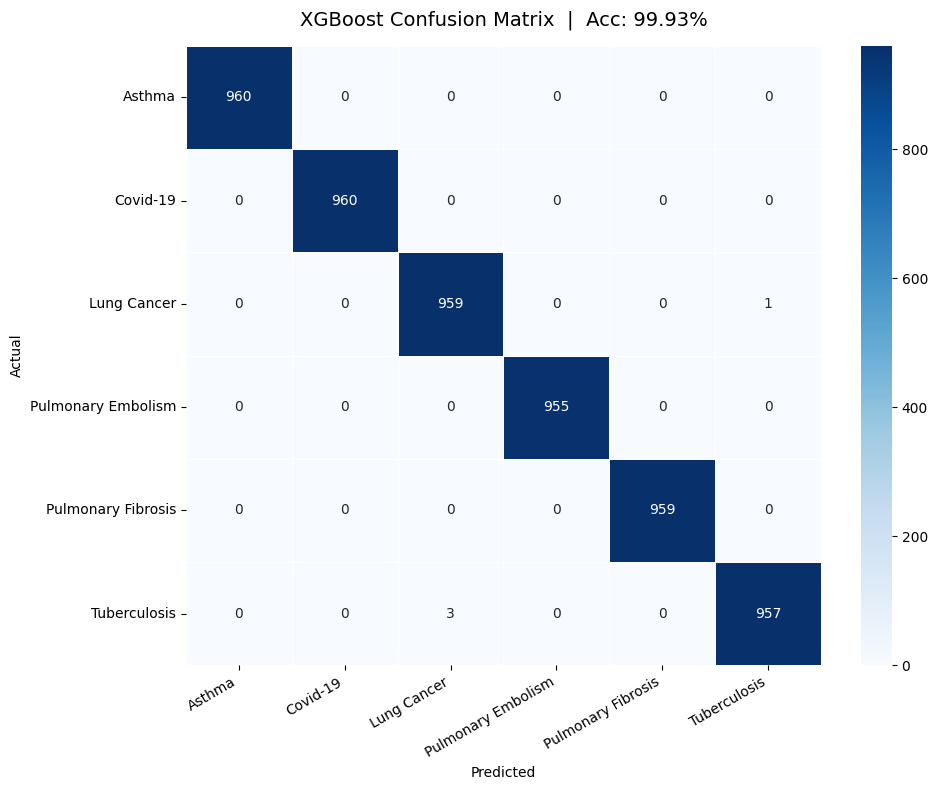

✅ Saved


In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.title(f'XGBoost Confusion Matrix  |  Acc: {acc:.2f}%', fontsize=14, pad=15)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/xgb_confusion_matrix.png', dpi=150); plt.show()
print('✅ Saved')

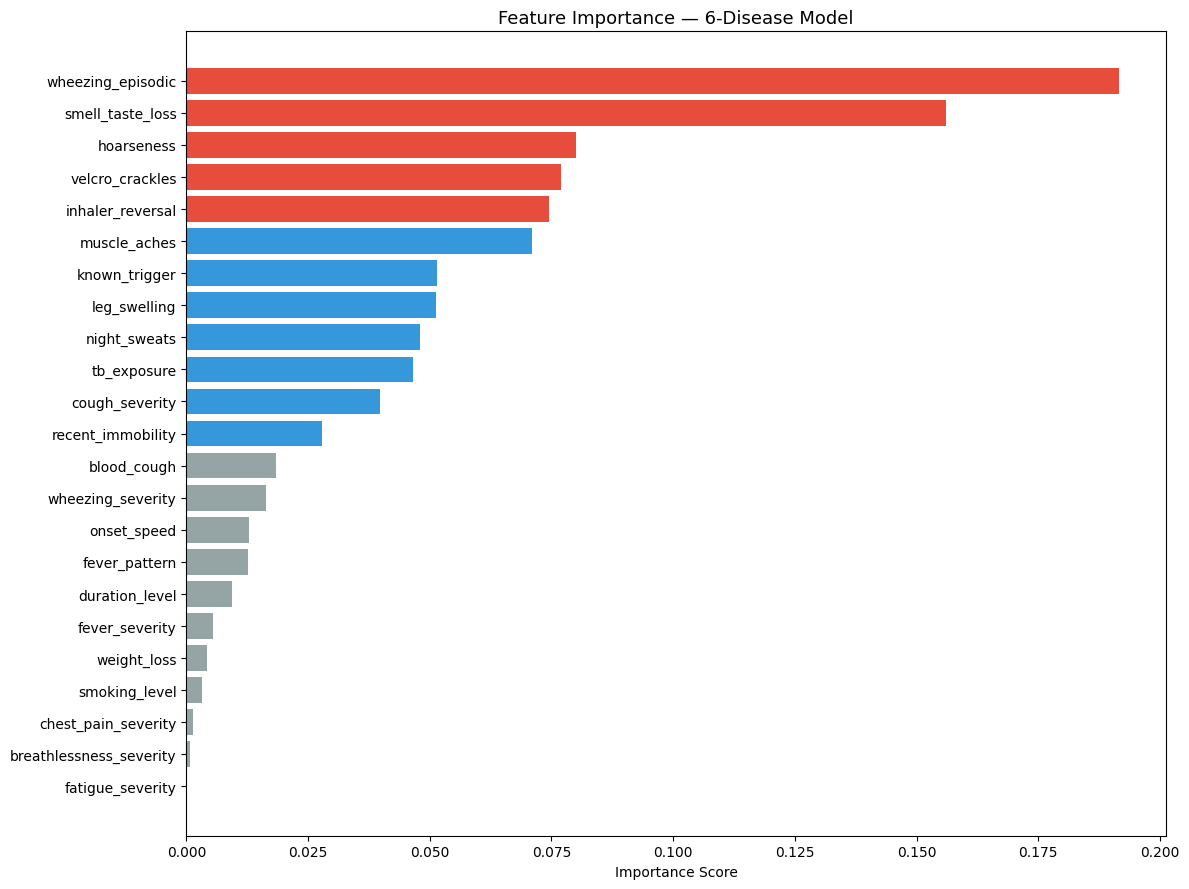

Top 10:
          Feature  Importance
wheezing_episodic    0.191577
 smell_taste_loss    0.156036
       hoarseness    0.080057
  velcro_crackles    0.076938
 inhaler_reversal    0.074533
     muscle_aches    0.070937
    known_trigger    0.051387
     leg_swelling    0.051362
     night_sweats    0.048054
      tb_exposure    0.046523


In [21]:
imp_df = pd.DataFrame({'Feature': ALL_FEATURES,
                        'Importance': model.feature_importances_
                       }).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 9))
colors = ['#e74c3c' if i < 5 else '#3498db' if i < 12 else '#95a5a6'
          for i in range(len(imp_df))]
plt.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color=colors[::-1])
plt.title('Feature Importance — 6-Disease Model', fontsize=13)
plt.xlabel('Importance Score'); plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/xgb_feature_importance.png', dpi=150); plt.show()
print('Top 10:')
print(imp_df.head(10).to_string(index=False))

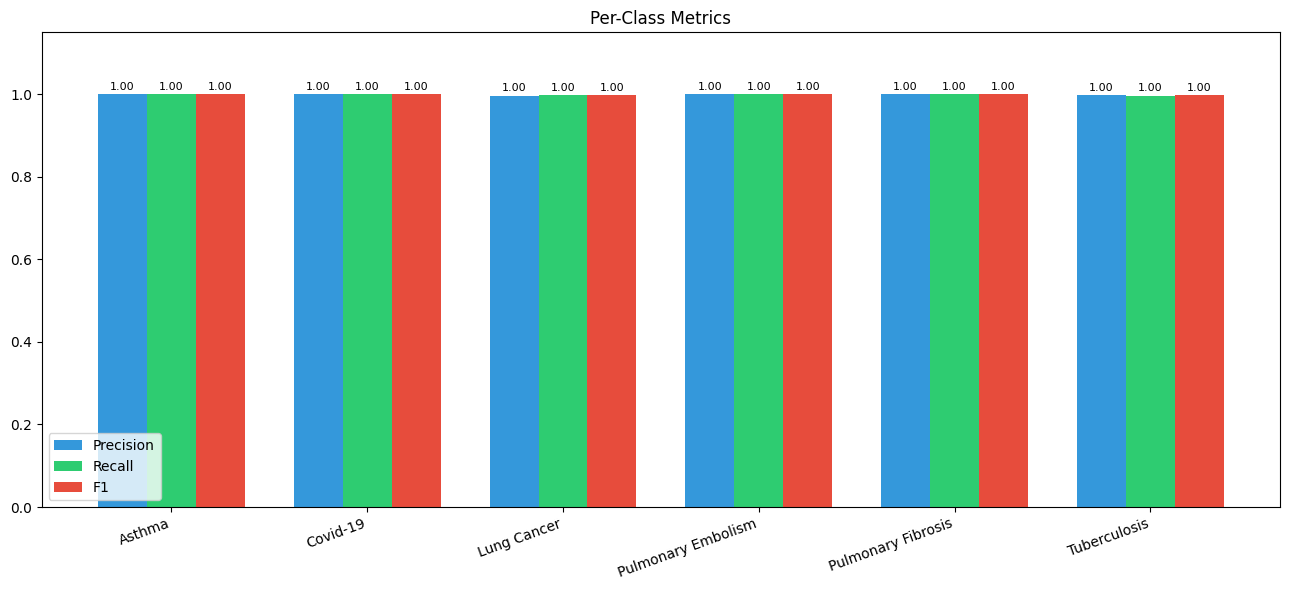

In [22]:
precision = precision_score(y_test, y_pred, average=None)
recall    = recall_score(y_test, y_pred, average=None)
f1        = f1_score(y_test, y_pred, average=None)

x = np.arange(len(le.classes_)); w = 0.25
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x-w, precision, w, label='Precision', color='#3498db')
ax.bar(x,   recall,    w, label='Recall',    color='#2ecc71')
ax.bar(x+w, f1,        w, label='F1',        color='#e74c3c')
for i in range(len(le.classes_)):
    ax.text(i-w, precision[i]+0.01, f'{precision[i]:.2f}', ha='center', fontsize=8)
    ax.text(i,   recall[i]+0.01,    f'{recall[i]:.2f}',    ha='center', fontsize=8)
    ax.text(i+w, f1[i]+0.01,        f'{f1[i]:.2f}',        ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(le.classes_, rotation=20, ha='right')
ax.set_ylim(0, 1.15); ax.set_title('Per-Class Metrics'); ax.legend()
plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/xgb_per_class_metrics.png', dpi=150); plt.show()

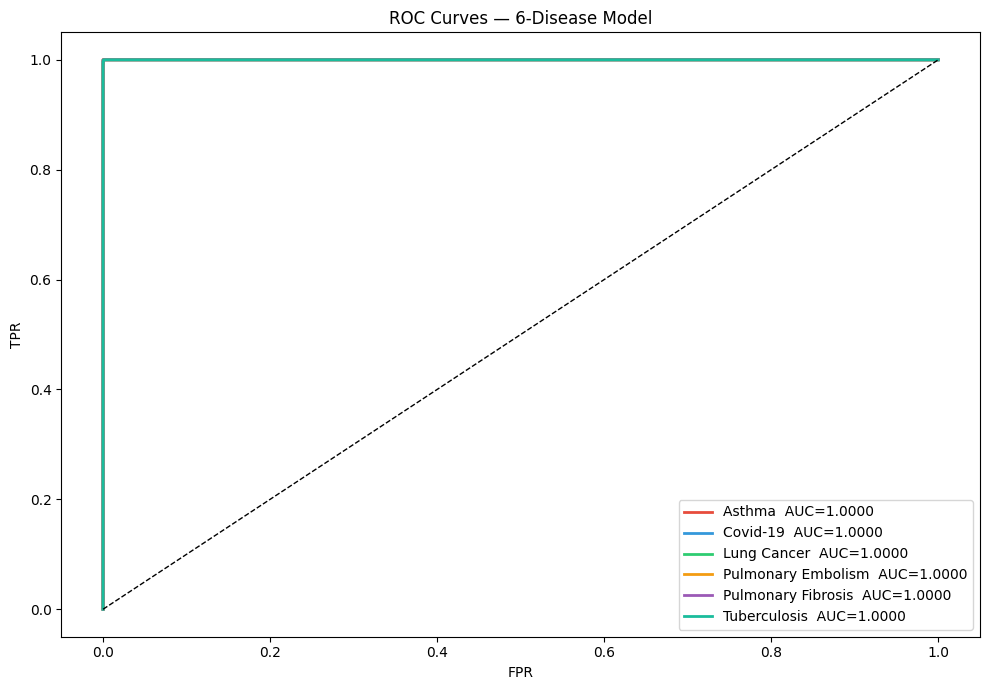

In [23]:
y_bin  = label_binarize(y_test, classes=list(range(len(le.classes_))))
y_prob = model.predict_proba(X_test)
pal    = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

plt.figure(figsize=(10, 7))
for i,(d,c) in enumerate(zip(le.classes_, pal)):
    fpr,tpr,_ = roc_curve(y_bin[:,i], y_prob[:,i])
    plt.plot(fpr, tpr, color=c, lw=2, label=f'{d}  AUC={auc(fpr,tpr):.4f}')
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves — 6-Disease Model'); plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/xgb_roc_curve.png', dpi=150); plt.show()

In [24]:
def predict_from_frontend(severity, adv_answers, smoking, duration, label=None, desc=None):
    vec      = frontend_to_features(severity, adv_answers, smoking, duration)
    input_df = pd.DataFrame([dict(zip(ALL_FEATURES, vec))])
    pred_enc = model.predict(input_df)[0]
    probs    = model.predict_proba(input_df)[0]
    pred_dis = le.classes_[pred_enc]
    top_conf = probs[pred_enc] * 100
    sorted_i = np.argsort(probs)[::-1]

    if desc:  print(f'  Patient  : {desc}')
    if label:
        st = '✅ CORRECT' if pred_dis == label else f'❌ Wrong (expected: {label})'
        print(f'  Expected : {label}  →  {st}')
    print(f'  ╔══════════════════════════════════════════╗')
    print(f'  ║  DIAGNOSIS  : {pred_dis:<26} ║')
    print(f'  ║  CONFIDENCE : {top_conf:>5.1f}%                     ║')
    print(f'  ╚══════════════════════════════════════════╝')
    secs = [(le.classes_[i], probs[i]*100) for i in sorted_i[1:] if probs[i]*100 > 15]
    if secs:
        print('  ⚠ Secondary possibilities (>15%):')
        for d,p in secs: print(f'     {d:<22} {p:.1f}%')
    return pred_dis, top_conf

print('✅ predict_from_frontend() defined')

✅ predict_from_frontend() defined


In [25]:
FRONTEND_TEST_CASES = [
    {'label': 'Covid-19',           'desc': 'Smell loss + fever + dry cough + muscle aches, sudden 24h onset',
     'severity': {'covid19': 2}, 'advAnswers': {'smell_taste_loss': True, 'muscle_aches': True, 'headache_fever': True, 'sudden_24h_onset': True}, 'smoking': 'non_smoker', 'duration': '1_week'},
    {'label': 'Covid-19',           'desc': 'High fever + complete smell/taste loss + breathlessness, sudden onset',
     'severity': {'covid19': 3}, 'advAnswers': {'smell_taste_loss': True, 'muscle_aches': True, 'sudden_24h_onset': True}, 'smoking': 'occasional', 'duration': '1_week'},
    {'label': 'Pulmonary Fibrosis', 'desc': 'Velcro crackles + dry cough + progressive breathlessness, zero fever, 3+ months',
     'severity': {'pulmonary_fibrosis': 2}, 'advAnswers': {'velcro_crackles': True, 'monthly_worsening': True, 'no_fever_ever': True, 'ex_smoker': True}, 'smoking': 'former', 'duration': '3_months'},
    {'label': 'Pulmonary Fibrosis', 'desc': 'Severe breathlessness at rest + velcro crackles, chronic, never-smoker',
     'severity': {'pulmonary_fibrosis': 3}, 'advAnswers': {'velcro_crackles': True, 'monthly_worsening': True, 'no_fever_ever': True, 'ex_smoker': True}, 'smoking': 'non_smoker', 'duration': '3_months'},
    {'label': 'Pulmonary Embolism', 'desc': 'Severe breathlessness in minutes + sharp chest pain + one-leg swelling, post-flight',
     'severity': {'pulmonary_embolism': 3}, 'advAnswers': {'minutes_onset': True, 'leg_swelling': True, 'heart_racing': True, 'immobility_risk': True}, 'smoking': 'non_smoker', 'duration': '1_3_days'},
    {'label': 'Pulmonary Embolism', 'desc': 'Sudden breathlessness + chest pain + leg swelling, no cough, no fever',
     'severity': {'pulmonary_embolism': 2}, 'advAnswers': {'minutes_onset': True, 'leg_swelling': True, 'immobility_risk': True}, 'smoking': 'regular', 'duration': '1_3_days'},
    {'label': 'Tuberculosis',       'desc': 'Drenching night sweats + blood cough + weight loss + TB contact, 3+ months',
     'severity': {'tuberculosis': 3}, 'advAnswers': {'drenching_sweats': True, 'chronic_cough_3w': True, 'unexplained_wt': True, 'tb_exposure': True}, 'smoking': 'non_smoker', 'duration': '3_months'},
    {'label': 'Tuberculosis',       'desc': 'Night sweats + 3-week cough + weight loss + TB travel history',
     'severity': {'tuberculosis': 2}, 'advAnswers': {'drenching_sweats': True, 'chronic_cough_3w': True, 'unexplained_wt': True, 'tb_exposure': True}, 'smoking': 'non_smoker', 'duration': '1_month'},
    {'label': 'Asthma',             'desc': 'Episodic wheeze + dust trigger + inhaler relief, fully normal between attacks',
     'severity': {'asthma': 1}, 'advAnswers': {'normal_between': True, 'specific_trigger': True, 'inhaler_relief': True, 'nocturnal_wheeze': True}, 'smoking': 'non_smoker', 'duration': '1_week'},
    {'label': 'Asthma',             'desc': 'Severe wheezing + breathlessness during attack, trigger-driven, full recovery between',
     'severity': {'asthma': 3}, 'advAnswers': {'normal_between': True, 'specific_trigger': True, 'inhaler_relief': True}, 'smoking': 'occasional', 'duration': '1_3_days'},
    {'label': 'Lung Cancer',        'desc': 'Haemoptysis + new hoarseness + weight loss, heavy smoker, insidious months',
     'severity': {'lung_cancer': 3}, 'advAnswers': {'blood_in_cough': True, 'new_hoarseness': True, 'cancer_wt_loss': True, 'heavy_smoker': True}, 'smoking': 'heavy', 'duration': '3_months'},
    {'label': 'Lung Cancer',        'desc': 'Chronic cough + blood streaks + hoarseness, regular smoker, 3+ months',
     'severity': {'lung_cancer': 2}, 'advAnswers': {'blood_in_cough': True, 'new_hoarseness': True, 'cancer_wt_loss': True}, 'smoking': 'regular', 'duration': '3_months'},
    {'label': 'Lung Cancer',        'desc': 'Blood cough + weight loss + hoarseness, NO night sweats, NO TB exposure → Cancer',
     'severity': {'lung_cancer': 2}, 'advAnswers': {'blood_in_cough': True, 'new_hoarseness': True, 'cancer_wt_loss': True, 'heavy_smoker': True}, 'smoking': 'heavy', 'duration': '3_months'},
    {'label': 'Pulmonary Fibrosis', 'desc': 'Dry cough + progressive breathlessness + velcro crackles, zero fever, no trigger',
     'severity': {'pulmonary_fibrosis': 2}, 'advAnswers': {'velcro_crackles': True, 'monthly_worsening': True, 'no_fever_ever': True}, 'smoking': 'former', 'duration': '3_months'},
]

print('=' * 70)
print('   FRONTEND-ALIGNED PATIENT TESTS — 6-DISEASE MODEL')
print('=' * 70)

correct = 0
for i, tc in enumerate(FRONTEND_TEST_CASES):
    print(f'\n── Test {i+1}/{len(FRONTEND_TEST_CASES)} ──────────────────────────────────────────')
    pred, conf = predict_from_frontend(
        tc['severity'], tc['advAnswers'], tc['smoking'], tc['duration'],
        label=tc['label'], desc=tc['desc']
    )
    if pred == tc['label']:
        correct += 1

print('\n' + '=' * 70)
print(f'   FRONTEND TEST ACCURACY : {correct}/{len(FRONTEND_TEST_CASES)} = {correct/len(FRONTEND_TEST_CASES)*100:.1f}%')
print('=' * 70)

   FRONTEND-ALIGNED PATIENT TESTS — 6-DISEASE MODEL

── Test 1/14 ──────────────────────────────────────────
  Patient  : Smell loss + fever + dry cough + muscle aches, sudden 24h onset
  Expected : Covid-19  →  ✅ CORRECT
  ╔══════════════════════════════════════════╗
  ║  DIAGNOSIS  : Covid-19                   ║
  ║  CONFIDENCE :  99.9%                     ║
  ╚══════════════════════════════════════════╝

── Test 2/14 ──────────────────────────────────────────
  Patient  : High fever + complete smell/taste loss + breathlessness, sudden onset
  Expected : Covid-19  →  ✅ CORRECT
  ╔══════════════════════════════════════════╗
  ║  DIAGNOSIS  : Covid-19                   ║
  ║  CONFIDENCE :  99.9%                     ║
  ╚══════════════════════════════════════════╝

── Test 3/14 ──────────────────────────────────────────
  Patient  : Velcro crackles + dry cough + progressive breathlessness, zero fever, 3+ months
  Expected : Pulmonary Fibrosis  →  ✅ CORRECT
  ╔═══════════════════════════

In [26]:
# ── CELL 20 · Save model files ───────────────────────────────
import zipfile

model_path   = f'{MODEL_DIR}/xgboost_6disease_v5.pkl'
encoder_path = f'{MODEL_DIR}/label_encoder_v5.pkl'
feature_path = f'{MODEL_DIR}/feature_list_v5.json'
mapping_path = f'{MODEL_DIR}/frontend_mapping_v5.json'

joblib.dump(model, model_path)
joblib.dump(le,    encoder_path)

with open(feature_path, 'w') as f:
    json.dump(ALL_FEATURES, f, indent=2)

with open(mapping_path, 'w') as f:
    json.dump({
        'SMOKING_MAP':  SMOKING_MAP,
        'DURATION_MAP': DURATION_MAP,
        'DISEASES':     DISEASES,
        'FEATURES':     ALL_FEATURES
    }, f, indent=2)

print('✅ xgboost_6disease_v5.pkl')
print('✅ label_encoder_v5.pkl')
print('✅ feature_list_v5.json')
print('✅ frontend_mapping_v5.json')

zip_path = f'{DRIVE_BASE}/mediscan_v5_files.zip'
with zipfile.ZipFile(zip_path, 'w') as z:
    for p in [model_path, encoder_path, feature_path, mapping_path,
               f'{GRAPH_DIR}/xgb_confusion_matrix.png',
               f'{GRAPH_DIR}/xgb_feature_importance.png',
               f'{GRAPH_DIR}/xgb_per_class_metrics.png',
               f'{GRAPH_DIR}/xgb_roc_curve.png']:
        z.write(p, os.path.basename(p))
print(f'\n✅ ZIP: {zip_path}')

✅ xgboost_6disease_v5.pkl
✅ label_encoder_v5.pkl
✅ feature_list_v5.json
✅ frontend_mapping_v5.json

✅ ZIP: /content/drive/MyDrive/MediScan_AI/mediscan_v5_files.zip


In [27]:
print('\n' + '=' * 70)
print('   MEDISCAN AI v4 — TRAINING COMPLETE')
print('=' * 70)
print(f'  Diseases          : {list(le.classes_)}')
print(f'  Total samples     : {len(synthetic_df):,}  ({TARGET_PER_CLASS:,}/disease)')
print(f'  Features          : {len(ALL_FEATURES)}')
print(f'  Test Accuracy     : {acc:.2f}%')
print(f'  Best XGB iter     : {model.best_iteration}')
print()
print('  SMOKING_MAP : non_smoker=0 former=1 occasional=2 regular=3 heavy=4')
print('  DURATION_MAP: 1_3_days=0  1_week=1  1_month=2    3_months=3')
print('=' * 70)


   MEDISCAN AI v4 — TRAINING COMPLETE
  Diseases          : [np.str_('Asthma'), np.str_('Covid-19'), np.str_('Lung Cancer'), np.str_('Pulmonary Embolism'), np.str_('Pulmonary Fibrosis'), np.str_('Tuberculosis')]
  Total samples     : 28,769  (4,800/disease)
  Features          : 23
  Test Accuracy     : 99.93%
  Best XGB iter     : 799

  SMOKING_MAP : non_smoker=0 former=1 occasional=2 regular=3 heavy=4
  DURATION_MAP: 1_3_days=0  1_week=1  1_month=2    3_months=3
